# Quantum Statistical Potential:<br> Two-Phase Mass Strategy for Efficient Thermalization

## Overview

The YAML input file can be found at [input_file](./input_files/QSP_Hansen.yaml)

In MD simulations involving electrons and ions, the large mass difference between these species creates a significant computational challenge. The time step must be chosen small enough to adequately sample electron dynamics, which occur on very fast timescales. However, ions evolve much more slowly, so sampling their dynamics requires very long simulations. This means that reaching thermal equilibrium, where both the fast electron and slow ion degrees of freedom are properly equilibrated, is computationally expensive. 

Usually the interaction potential between particles does not depend on their masses, *e.g.* Coulomb. As such we could speed up the thermalization phase by using the same mass for both particle species and then switch back for the production phase. In* QSP simulations, however, the interaction potential inherently depends on the reduced mass between particle pairs. This means that using different masses affects both the potential and the resulting dynamics. The solution is to use the correct mass for the interaction potential and equal masses for the integrator. 

This tutorial shows to implement a practical two-phase approach that accelerates the thermalization phase while maintaining physical accuracy in production runs. By temporarily equalizing the particle masses during thermalization, we can dramatically reduce the time needed to reach equilibrium. Once thermalized, we switch back to realistic masses for the production phase where observables are measured. This simple trick significantly reduces overall simulation time without compromising the physical validity of the results.

## Outline Strategy

The steps are the following

1. Create an input file with the correct mass of ions and electrons.
2. Calculate the diffractive lengths for ions and electrons.
3. Update the input file with equal masses and correct diffractive lengths
4. Run the equilibration phase
5. Check that the system is thermalized by running a short production phase
6. Update the input file with the correct masses and run a simulation without equilibration
 


In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os

plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess

from sarkas.tools.observables import ElectricCurrent, Thermodynamics, RadialDistributionFunction

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files',  'QSP_Hansen.yaml')


/Users/silves28/anaconda3/envs/sarkas/lib/python3.10/site-packages/pyfiglet/__init__.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:

pre = PreProcess(input_file_name)
pre.setup(read_yaml=True)
pre.run(
    loops = 20,  # Number of loops to average for the timing estimate
    timing = True, # Estimate the time to run the simulation
    pppm_estimate=True # Make plots of the PPPM parameter estimation
    )

Once we are satisfied with all our simulation parameters, *e.g.* thermostat, timesteps, Ewald parameters etc., we collect the diffractive lengths from `potential.matrix` and use them in the short equilibration phase

In [ ]:
# Collect the de-Broglie wavelengths from the potential matrix

if pre.potential.qsp_type == 'kelbg':
    lambda_ei = np.sqrt(2.0 * np.pi) / pre.potential.matrix[0,1,1]
    lambda_ee = np.sqrt(2.0 * np.pi) / pre.potential.matrix[0,0,1]
else:
    lambda_ei = 2.0 * np.pi / pre.potential.matrix[0,1,1]
    lambda_ee = 2.0 * np.pi / pre.potential.matrix[0,0,1]

print(f"ei_diffractive_length: {lambda_ei:.15e}")
print(f"ee_diffractive_length: {lambda_ee:.15e}")


## Thermalization Phase

The next cell updates the input file by 
1. using the same mass for the electrons and protons. To do this we need to replace the `Particles` section with the new species. Notice the `replace` attribute in each species
2. updating the `Potential` section with the real-mass diffractive lengths.
3. reducing the number of `production_steps` since we only want a small simulation to check thermalization
   
   

In [ ]:
new_args = {
        "Particles": [
            {"Species": {
                "name": "e",
                "number_density": 1.6e+24,       # N/cc
                "mass": 9.1093837015e-28,        # g, electron mass
                "num": 1024,
                "Z": -1.0,                       # degree of ionization
                "temperature": 6.32e+5,   # K                   # 54.4 eV
                "replace": True},         # <=== This is needed to replace the particles from the YAML file
            },
            {"Species": {
                "name": "p",
                "number_density": 1.6e+24,       # N/cc
                "mass": 9.1093837015e-28,        # <=== Notice the same mass of the electrons
                "num": 1024,
                "Z": 1.0,                       # degree of ionization
                "temperature": 6.32e+5,   # K                   # 54.4 eV
                "replace": True}     # <=== This is needed to replace the particles from the YAML file
            }
        ],
        # Update the Potential class parameters with the real-mass diffractive lengths
        "Potential": {
            "ei_diffractive_length": 9.378635273022549e-09,
            "ee_diffractive_length": 1.325978293939958e-08
        },
        "Integrator": {
            "production_steps" : 10_000, # <=== We don't require long production runs for testing
            # 'qmc_sequence': 'sobol'
        },
        "IO": {
            "verbose": True,   # No need to output the progress bar
        },
    }

sim = Simulation(input_file_name)
sim.setup(read_yaml=True, other_inputs=new_args)


In [ ]:
sim.run()

In [ ]:
path = os.path.join('input_files', "particles_init.npz")
sim.particles.dump_arrays(path, data_to_save=['id', 'names', 'pos', 'vel'])

### Thermalization Check

In order to check that the system is equilibrated we will plot the temperature and total energy of the system of the production phase. If the system is thermalized these two time series will be stationary which means that their mean and variance do not depend on time and are constant.

To do this we use the `PostProcess` class and the `Thermodynamics` class. The `PostProcess` class is needed to read the simulation's parameters and pass it to the `Thermodynamics` class which will handle reading and processing the saved data. 

In [ ]:
# Save particles to npz file for post-processing


In [ ]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True, other_inputs=new_args)

In [ ]:
# Equilibration check just for the sake of completeness
# The energy need not be constant in this case, but we want to see the temperature approach the target value
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters, phase = "equilibration")
therm.temp_energy_plot(postproc, )

In [ ]:
# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters)
therm.temp_energy_plot(postproc)

## Production phase

In [2]:
new_args = {
        # "Particles": [
        #     {"Species": {
        #         "name": "e",
        #         "number_density": 1.6e+24,       # N/cc
        #         "mass": 9.1093837015e-28,        # g, electron mass
        #         "num": 1024,
        #         "Z": -1.0,                       # degree of ionization
        #         "temperature": 6.32e+5,   # K                   # 54.4 eV
        #         "replace": True},         # <=== This is needed to replace the particles from the YAML file
        #     },
        #     {"Species": {
        #         "name": "e",
        #         "number_density": 1.6e+24,       # N/cc
        #         "mass": 9.1093837015e-28,        # <=== Notice the same mass of the electrons
        #         "num": 1024,
        #         "Z": 1.0,                       # degree of ionization
        #         "temperature": 6.32e+5,   # K                   # 54.4 eV
        #         "replace": True}     # <=== This is needed to replace the particles from the YAML file
        #     }
        # ],
        # Update the Potential class parameters with the real-mass diffractive lengths
        # "Potential": {
        #     "ei_diffractive_length": 9.378635273022549e-09,
        #     "ee_diffractive_length": 1.325978293939958e-08
        # },
        # "Integrator": {
        #     "production_steps" : 73_000, # <=== We don't require long production runs for testing
        # },
        "Parameters": {
            "load_method": "file",
            "particles_input_file": "input_files/particles_init.npz",
            # "restart_step": 0,  # Load the last step
        },
        "IO": {
            "verbose": True,   # No need to output the progress bar.
            # Note that we don't want to overwrite each simulation
            # So we save each simulation in its own folder by passing
            # a dictionary of dictionary with folder's name
        },
    }


In [3]:

# sim = Simulation(input_file_name)
# sim.setup(read_yaml=True, other_inputs=new_args)
# sim.run()



Estimating PPPM parameters...


=========================== Thermodynamics ===========================
Data saved in: 
 SarkasSimulations/qsp_hansen/PostProcessing/Thermodynamics/Production/Thermodynamics_qsp_hansen.h5
Data accessible via: self.dataframe_slices, self.dataframe

Time Series Data:
No. of blocks = 1
No. dumps per block = 7301
Total time per block: T = 3.0419e-14 [s] ~ 346 plasma periods
Time interval: dt = 4.1670e-18 [s] ~ 4.7e-02 plasma period


(<Figure size 2000x800 with 7 Axes>,
 {'main_plot': <Axes: xlabel='Time [fs]', ylabel='Temperature [eV]'>,
  'hist_plot': <Axes: >,
  'delta_plot': <Axes: ylabel='Deviation [%]'>},
 {'main_plot': <Axes: xlabel='Time [fs]', ylabel='Total Energy [keV]'>,
  'hist_plot': <Axes: >,
  'delta_plot': <Axes: ylabel='Deviation [%]'>})

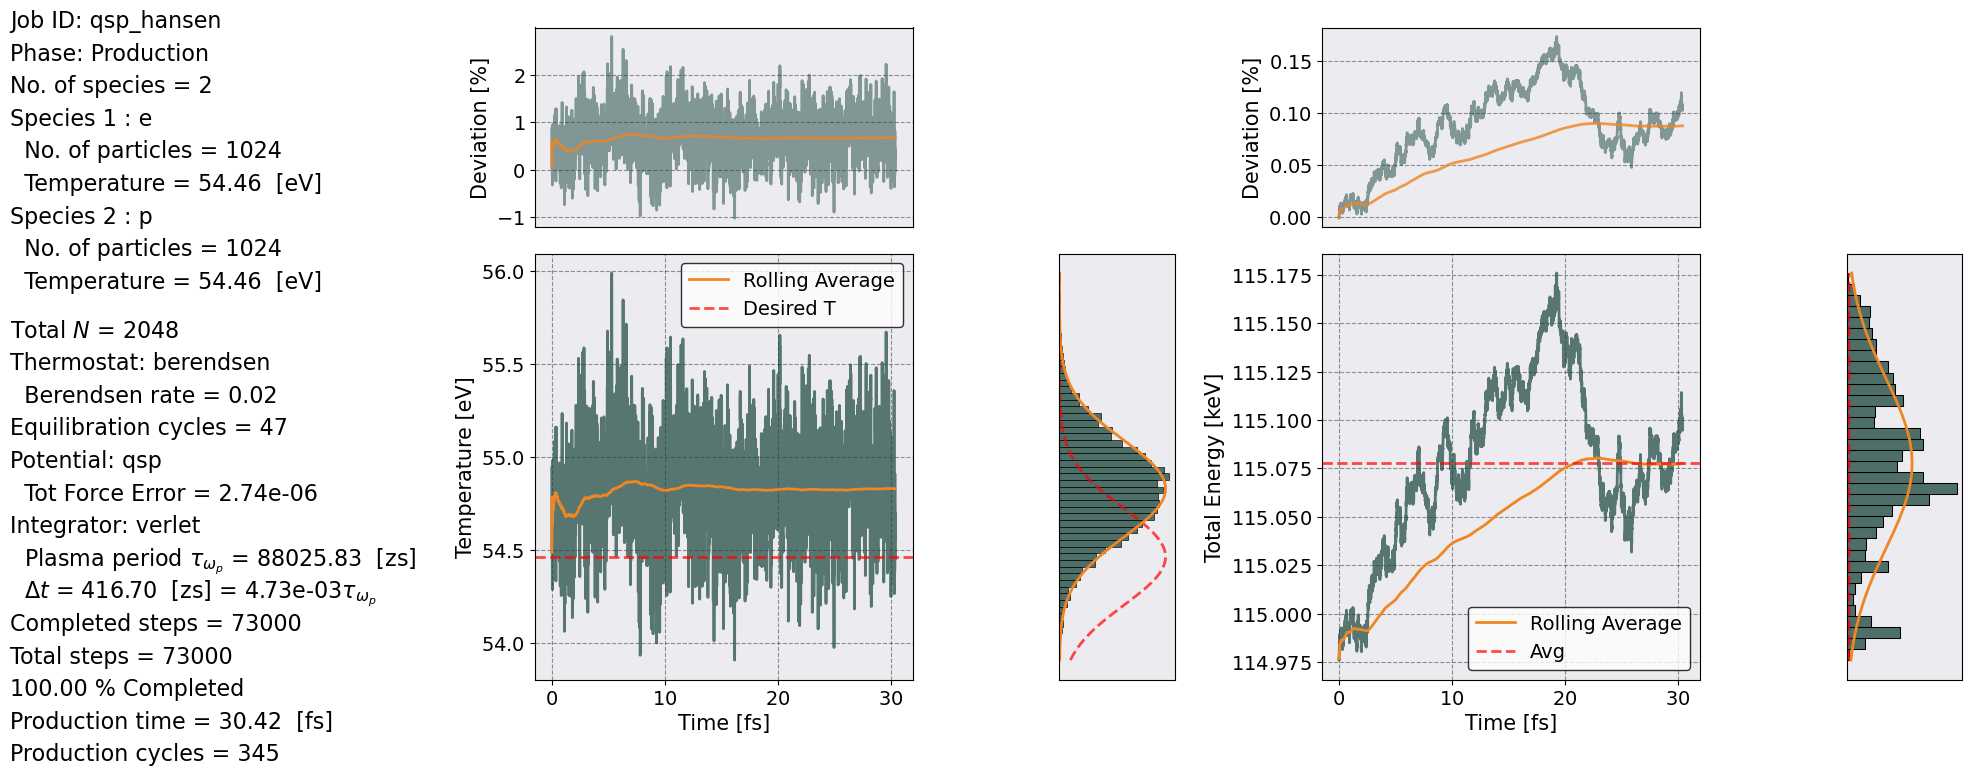

In [4]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True, other_inputs=new_args)

# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters, )
therm.temp_energy_plot(postproc)

In [38]:
# Radial Distribution Function 
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()
# Grab HNC data for comparison
# hnc_r, hnc_gee, hnc_gei, hnc_gii = np.loadtxt('hnc_gall.out', unpack=True)



==================== Radial Distribution Function ====================
Data saved in: 
 SarkasSimulations/qsp_hansen/PostProcessing/RadialDistributionFunction/Production/RadialDistributionFunction_qsp_hansen.h5
Data accessible via: self.dataframe_slices, self.dataframe
No. bins = 51
dr = 0.1505 a_ws = 6.3366e-10 [cm]
Maximum Distance (i.e. potential.rc)= 7.6766 a_ws = 3.2317e-08 [cm]
Time Series Data:
No. of blocks = 1
No. dumps per block = 7301
Total time per block: T = 3.0419e-14 [s] ~ 346 plasma periods
Time interval: dt = 4.1670e-18 [s] ~ 4.7e-02 plasma period


Calculating RDF for slice:   0%|          | 0/1 [00:00<?, ?it/s]


Radial Distribution Function Calculation Time: 0 sec 45 msec 857 usec 917 nsec


In [39]:
rdf.dataframe.head()

Interparticle   e-e RDF       e-p RDF       p-p RDF    
       Distance      Mean Std      Mean Std      Mean Std
0  0.000000e+00  1.144496 NaN  3.093646 NaN  0.010287 NaN
1  9.504859e-10  1.142241 NaN  2.395644 NaN  0.144092 NaN
2  1.584143e-09  1.132917 NaN  1.962598 NaN  0.374790 NaN
3  2.217800e-09  1.119565 NaN  1.691399 NaN  0.561456 NaN
4  2.851458e-09  1.105276 NaN  1.505592 NaN  0.702019 NaN

[(-0.2, 6.0),
 Text(0.5, 141.00000000000014, '$r/a_e$'),
 Text(59.085149129231766, 0.5, '$g(r)$')]

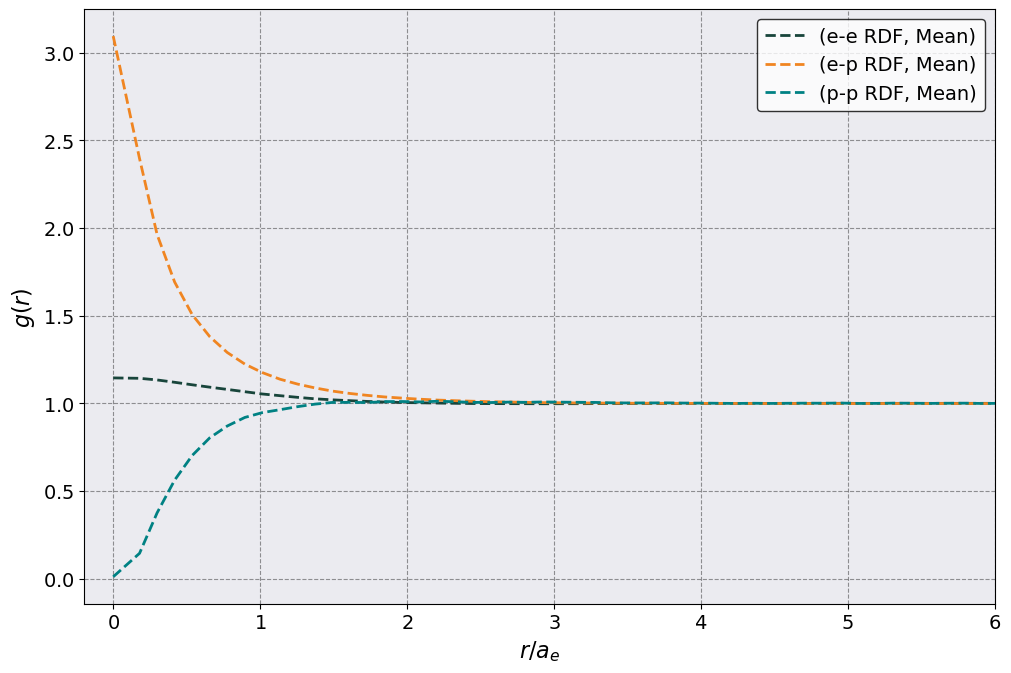

In [40]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
# ax.plot(hnc_r , hnc_gee, label = 'hnc e-e RDF')
# ax.plot(hnc_r , hnc_gei, label = 'hnc e-p RDF')
# ax.plot(hnc_r , hnc_gii, label = 'hnc p-p RDF')
rdf.plot(scaling = postproc.species[0].a_ws, 
                  y = [('e-e RDF', "Mean"),
                       ('e-p RDF', "Mean"),
                       ('p-p RDF', "Mean")
                      ],
                  ax = ax, 
                  ls = '--')
ax.legend()
ax.set(xlim = (-0.2, 6), xlabel = r'$r/a_e$', ylabel = r"$g(r)$")

In [8]:
ec = ElectricCurrent()
ec.setup(postproc.parameters)
ec.compute(calculate_acf=True)
# ec.parse()




========================== Electric Current ==========================
Data saved in: 
 SarkasSimulations/qsp_hansen/PostProcessing/ElectricCurrent/Production/ElectricCurrent_qsp_hansen.h5
Data accessible via: self.dataframe_slices, self.dataframe

Time Series Data:
No. of blocks = 1
No. dumps per block = 7301
Total time per block: T = 3.0419e-14 [s] ~ 346 plasma periods
Time interval: dt = 4.1670e-18 [s] ~ 4.7e-02 plasma period



Calculating Electric Current for slice :   0%|          | 0/1 [00:00<?, ?it/s]


Electric Current calculation Time: 0 sec 65 msec 601 usec 959 nsec



Calculating Electric Current ACF for slice :   0%|          | 0/1 [00:00<?, ?it/s]


Electric Current ACF calculation Time: 0 sec 51 msec 948 usec 333 nsec


In [15]:
ec.dataframe

Electric Current                                                        \
              Species             e                                           
                 Axis             X                 Y                 Z       
                 Time          Mean Std          Mean Std          Mean Std   
0        0.000000e+00  4.283664e-15 NaN  2.977450e-15 NaN -6.584746e-16 NaN   
1        4.167000e-18  6.005209e-01 NaN -8.674470e-01 NaN  3.206545e-01 NaN   
2        8.334000e-18  9.711177e-01 NaN -2.230149e+00 NaN  8.059970e-01 NaN   
3        1.250100e-17  8.787158e-01 NaN -3.281275e+00 NaN  7.607388e-01 NaN   
4        1.666800e-17  5.604374e-01 NaN -3.470309e+00 NaN  9.858962e-01 NaN   
...               ...           ...  ..           ...  ..           ...  ..   
7296     3.040243e-14  1.183596e+00 NaN -2.905740e+00 NaN -7.485387e-01 NaN   
7297     3.040660e-14  2.530499e+00 NaN -2.718426e+00 NaN -5.087012e-01 NaN   
7298     3.041077e-14  4.050720e+00 NaN -2.765455e+00 NaN  2.099225e-01 NaN   
7299     3.041493e-14  5.801710e+00 NaN -2.417252e+00 NaN  1.394203e+00 NaN   
7300     3.041910e-14  6.673203e+00 NaN -2.252084e+00 NaN  2.104561e+00 NaN   

                                                            
                 p                                          
                 X                 Y                 Z      
              Mean Std          Mean Std          Mean Std  
0     1.073600e-17 NaN  7.604666e-18 NaN  3.578666e-17 NaN  
1     3.270539e-04 NaN -4.724264e-04 NaN  1.746339e-04 NaN  
2     5.288872e-04 NaN -1.214577e-03 NaN  4.389597e-04 NaN  
3     4.785636e-04 NaN -1.787038e-03 NaN  4.143113e-04 NaN  
4     3.052237e-04 NaN -1.889989e-03 NaN  5.369358e-04 NaN  
...            ...  ..           ...  ..           ...  ..  
7296  6.446066e-04 NaN -1.582515e-03 NaN -4.076669e-04 NaN  
7297  1.378153e-03 NaN -1.480501e-03 NaN -2.770473e-04 NaN  
7298  2.206091e-03 NaN -1.506114e-03 NaN  1.143273e-04 NaN  
7299  3.159710e-03 NaN -1.316477e-03 NaN  7.593067e-04 NaN  
7300  3.634340e-03 NaN -1.226523e-03 NaN  1.146180e-03 NaN  

[7301 rows x 13 columns]

<Axes: xlabel='(Electric Current, Species, Axis, Time)'>

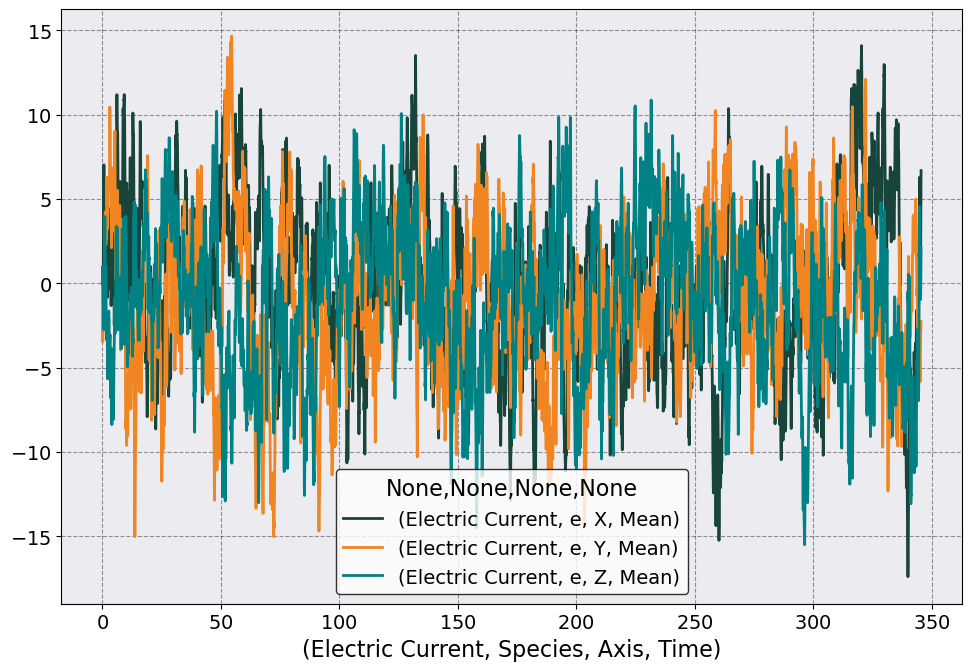

In [20]:
# Plot the e-e ACF normalized by its value at t=0
ec.plot(scaling = ec.plasma_period,
        y = [('Electric Current','e', 'X', 'Mean'), 
             ('Electric Current','e', 'Y', 'Mean'), 
             ('Electric Current','e', 'Z', 'Mean')],
        # acf = True
        )

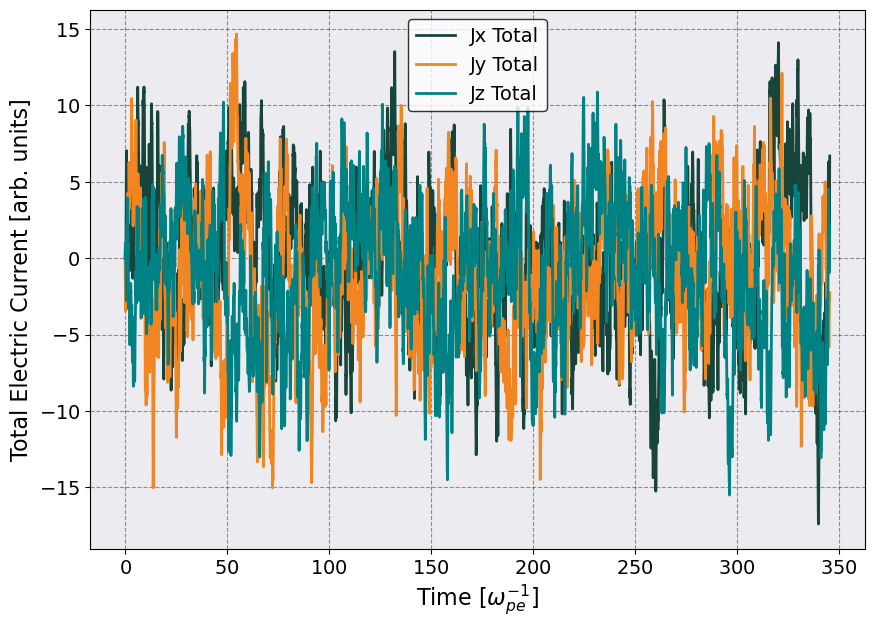

In [26]:
# Total current 
je = ec.dataframe[[('Electric Current','e', 'X', 'Mean'), 
                   ('Electric Current','e', 'Y', 'Mean'), 
                   ('Electric Current','e', 'Z', 'Mean')]].values
ji = ec.dataframe[[('Electric Current','p', 'X', 'Mean'), 
                   ('Electric Current','p', 'Y', 'Mean'), 
                   ('Electric Current','p', 'Z', 'Mean')]].values

J_total = je + ji

fig, ax = plt.subplots(1,1, figsize=(10,7))
time = ec.dataframe[('Electric Current','Species', 'Axis', 'Time')].values / ec.plasma_period
ax.plot(time, J_total[:,0], label='Jx Total')
ax.plot(time, J_total[:,1], label='Jy Total')
ax.plot(time, J_total[:,2], label='Jz Total')
ax.set(xlabel = r'Time [$\omega_{pe}^{-1}$]', ylabel = r'Total Electric Current [arb. units]')
ax.legend()


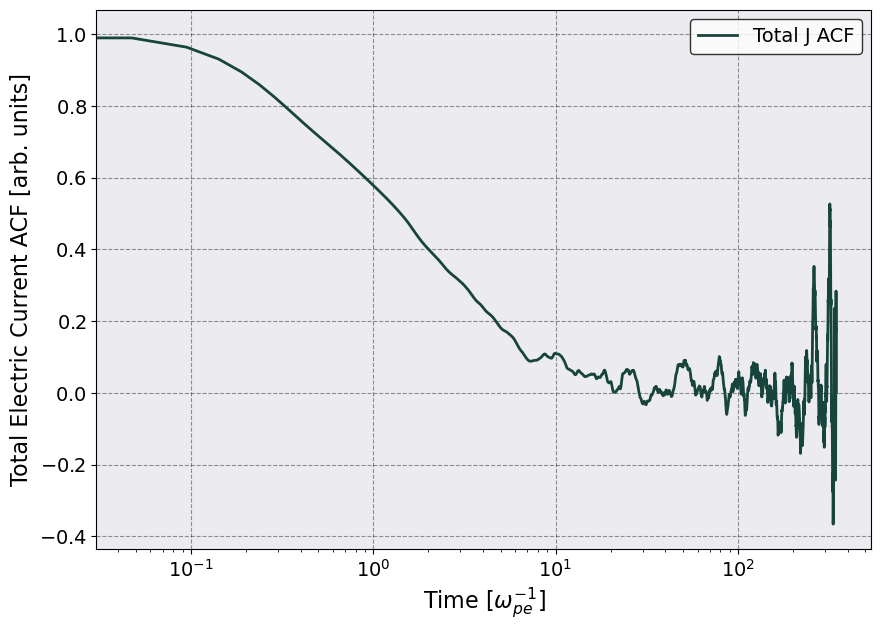

In [29]:
from sarkas.utilities.maths import correlationfunction


acf_jx = correlationfunction(J_total[:,0], J_total[:,0])
acf_jy = correlationfunction(J_total[:,1], J_total[:,1])
acf_jz = correlationfunction(J_total[:,2], J_total[:,2])

acf_J = (acf_jx + acf_jy + acf_jz)

fig, ax = plt.subplots(1,1, figsize=(10,7))

ax.plot(time, acf_J / acf_J[0], label='Total J ACF')
ax.set(
    xlabel = r'Time [$\omega_{pe}^{-1}$]',
    ylabel = r'Total Electric Current ACF [arb. units]',
    xscale = 'log',)
ax.legend()


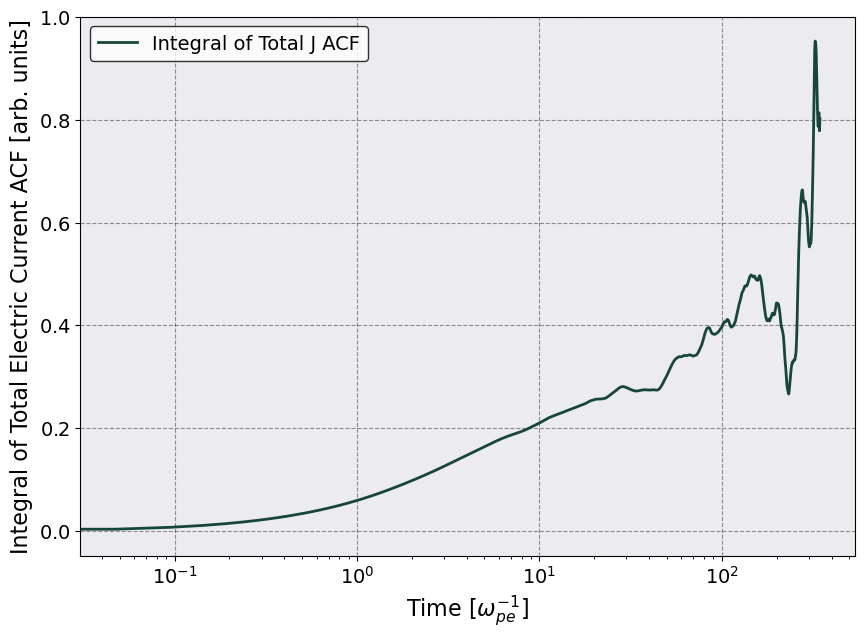

In [34]:
from scipy.integrate import cumulative_trapezoid

int_acf_J = cumulative_trapezoid(acf_J / acf_J[0], time, initial=0) / (4 * np.pi)

fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(time, int_acf_J, label='Integral of Total J ACF')
ax.set(
    xlabel = r'Time [$\omega_{pe}^{-1}$]',
    ylabel = r'Integral of Total Electric Current ACF [arb. units]',
    xscale = 'log',)
ax.legend()

In [70]:
# Fit a gaussian to the initial decay of the e-e ACF
from scipy.optimize import curve_fit

def gaussian(x, a, b):
    return 1 - 0.5 * (x * b)**2
    # return a * np.exp(-0.5 * (x/b)**2)

popt, pcov = curve_fit(gaussian, time[:64], acf_J[:64] / acf_J[0],
                       p0=[1, 0.1])
print(f"Fitted parameters: a = {popt[0]:.5f}, b = {popt[1]:.5f} s^-1 = {popt[1] * (2.0 * np.pi):.5f} rad/s")


Fitted parameters: a = 1.00000, b = 0.47581 s^-1 = 2.98962 rad/s


/var/folders/cq/63hr2pgs2m1_z45dj0_n28wm0000gp/T/ipykernel_67748/3285480258.py:8: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian, time[:64], acf_J[:64] / acf_J[0],


In [66]:
np.where( np.isclose(acf_J/ acf_J[0], 0.3, atol=1e-2) )

(array([  64,   65,   66,   67,   68,   69, 5459, 5460, 5461, 5462, 5463,
        5464, 5465, 5466, 5467, 5468, 5477, 5478, 5479, 5480, 5481, 5482,
        5483, 5484, 5485, 5549, 5550, 5551, 5552, 5553, 6634, 6635, 6636,
        6637, 6638, 6650, 6651, 6652, 6653, 6654, 6655, 6656, 6657, 6658,
        6659, 6660, 6661, 6662, 6663, 6664, 6665, 6666, 6667, 6668, 6686,
        6687, 6688, 6689, 6809, 6810, 6811]),)

In [75]:
from scipy.integrate import quad

h_ei = rdf.dataframe[('e-p RDF', 'Mean')].values - 1.0
h_ee = rdf.dataframe[('e-e RDF', 'Mean')].values - 1.0
h_pp = rdf.dataframe[('p-p RDF', 'Mean')].values - 1.0

r = rdf.dataframe[('Interparticle', 'Distance')].values
reduced_mass = (postproc.species[0].mass + postproc.species[1].mass) / (postproc.species[0].mass * postproc.species[1].mass)

d2V_dr2 = postproc.potential.potential_derivatives(r[1:], postproc.potential.matrix[0,1])[2]
integral = np.trapezoid(r[1:]**2 * h_ei[1:] * d2V_dr2, r[1:])

# Integrate
wj = 4.0 * np.pi * reduced_mass * postproc.parameters.species_num_dens[0] * integral /3 
print(f"Calculated wj: {wj/ec.total_plasma_frequency**2:.5e} rad/s")
# Compare to total plasma frequency squared


Calculated wj: -1.36918e+00 rad/s


In [80]:
# VACF 

d2V_ee_dr2 = postproc.potential.potential_derivatives(r[1:], postproc.potential.matrix[0,0])[2]
d2V_pp_dr2 = postproc.potential.potential_derivatives(r[1:], postproc.potential.matrix[1,1])[2]
integrad_e = (h_ei[1:] + 1 ) * d2V_dr2 + (h_ee[1:] + 1 ) * d2V_ee_dr2
integrad_p = (h_ei[1:] + 1 ) * d2V_dr2 + (h_pp[1:] + 1 ) * d2V_pp_dr2

integral_e = np.trapezoid(r[1:]**2 * integrad_e, r[1:])
integral_p = np.trapezoid(r[1:]**2 * integrad_p, r[1:])

wj_e = -4.0 * np.pi * postproc.parameters.species_num_dens[0] / postproc.species[0].mass * integral_e /3
wj_p = -4.0 * np.pi * postproc.parameters.species_num_dens[1] / postproc.species[1].mass * integral_p /3

print(f"Calculated wj_e: {np.sqrt(wj_e)/ec.total_plasma_frequency:.5e} rad/s")
print(f"Calculated wj_p: {np.sqrt(wj_p)/ec.total_plasma_frequency:.5e} rad/s")


Calculated wj_e: 2.41714e+01 rad/s
Calculated wj_p: 3.72433e-02 rad/s


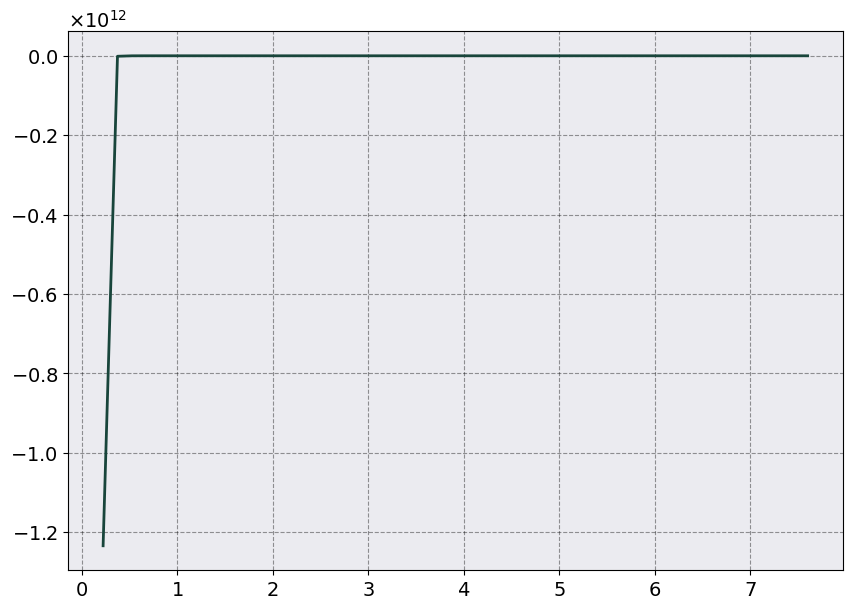

In [92]:
beta = 1.0 / (postproc.species[0].kB * postproc.species[0].temperature)
plt.plot(r[1:]/rdf.a_ws, d2V_ee_dr2 )
# plt.yscale('symlog', linthresh=1e9)